# Nova Corrected Dataset Exploration

This notebook compares the original synthetic parquet tables with the corrected BigQuery-ready parquet outputs in `data/corrected/`.

The goal is not deep modeling. The goal is to quickly check whether the corrected tables now behave more like a real global super-app dataset: growth, seasonality, market geography, merchant concentration, category-specific basket sizes, and non-flat reliability patterns.

## 1. Setup

Use Polars lazy scans for the interaction tables. Dimension tables and aggregate outputs are small enough to collect eagerly.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(80)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

NOTEBOOK_CWD = Path.cwd().resolve()
REPO_ROOT = NOTEBOOK_CWD if (NOTEBOOK_CWD / "data").exists() else NOTEBOOK_CWD.parent

RAW_DIR = REPO_ROOT / "data" / "raw"
CORRECTED_DIR = REPO_ROOT / "data" / "corrected"
QA_DIR = CORRECTED_DIR / "qa"

RAW_INTERACTIONS = RAW_DIR / "nova_interactions.parquet"
CORRECTED_INTERACTIONS_GLOB = str(CORRECTED_DIR / "nova_interactions" / "month=*" / "*.parquet")

print("Repo root:", REPO_ROOT)
print("Corrected interactions glob:", CORRECTED_INTERACTIONS_GLOB)

Repo root: /Users/doruk/dev/nova-analytics
Corrected interactions glob: /Users/doruk/dev/nova-analytics/data/corrected/nova_interactions/month=*/*.parquet


In [2]:
raw_interactions = pl.scan_parquet(RAW_INTERACTIONS)
corrected_interactions = pl.scan_parquet(CORRECTED_INTERACTIONS_GLOB)

raw_users = pl.read_parquet(RAW_DIR / "nova_users.parquet")
raw_services = pl.read_parquet(RAW_DIR / "nova_services.parquet")

corrected_users = pl.read_parquet(CORRECTED_DIR / "nova_users.parquet")
corrected_services = pl.read_parquet(CORRECTED_DIR / "nova_services.parquet")
markets = pl.read_parquet(CORRECTED_DIR / "nova_markets.parquet")

metadata_path = CORRECTED_DIR / "_generation_metadata.json"
metadata = json.loads(metadata_path.read_text()) if metadata_path.exists() else {}

display(pd.DataFrame([metadata]).T.rename(columns={0: "value"}))

,value
generated_at,2026-06-09T10:42:32Z
seed,20260609
target_rows,50000000
batch_size,1000000
month_counts,"{'2024-01': 3300000, '2024-02': 3200000, '2024..."
source_raw_dir,data/raw
output_dir,data/corrected


## 2. BigQuery readiness snapshot

This table is generated by `scripts/validate_corrected_dataset.py`. It should be the first sanity check before BigQuery ingestion.

In [3]:
checks_path = QA_DIR / "validation_checks.csv"
if checks_path.exists():
    validation_checks = pl.read_csv(checks_path)
    display(validation_checks.to_pandas())
else:
    print("No validation checks found. Run scripts/validate_corrected_dataset.py first.")

,check,status,detail
0,Exact target row count,PASS,"50,000,000 / 50,000,000"
1,Unique Transaction_UUID,PASS,"50,000,000 unique"
2,All required columns present,PASS,all present
3,Zero nulls in required columns,PASS,0 nulls
4,Full date coverage,PASS,0 missing dates
5,Category matches service category,PASS,0 mismatches
6,User FK coverage,PASS,0 missing
7,Service FK coverage,PASS,0 missing
8,Annual active user rate,PASS,84.95%
9,Lifetime repeat user rate,PASS,84.69%


## 3. Structural comparison

The corrected data should keep the same core analytical shape while fixing category-service consistency and date coverage.

In [4]:
def structural_profile(name: str, interactions_lf: pl.LazyFrame, services_df: pl.DataFrame) -> pl.DataFrame:
    base = interactions_lf.select(
        pl.len().alias("n_rows"),
        pl.col("Transaction_UUID").n_unique().alias("unique_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Service_ID").n_unique().alias("active_services"),
        pl.col("Date").min().alias("min_date"),
        pl.col("Date").max().alias("max_date"),
        pl.col("Date").n_unique().alias("n_dates"),
    ).collect()

    mismatches = (
        interactions_lf.select("Service_ID", "Category")
        .join(
            services_df.select("Service_ID", pl.col("Category").alias("Service_Category")).lazy(),
            on="Service_ID",
            how="left",
        )
        .select((pl.col("Category") != pl.col("Service_Category")).sum().alias("category_mismatches"))
        .collect()
    )
    return base.with_columns(
        pl.lit(name).alias("dataset"),
        pl.lit(mismatches.item()).alias("category_mismatches"),
    ).select("dataset", "n_rows", "unique_transactions", "active_users", "active_services", "min_date", "max_date", "n_dates", "category_mismatches")

profiles = pl.concat([
    structural_profile("raw", raw_interactions, raw_services),
    structural_profile("corrected", corrected_interactions, corrected_services),
])

display(profiles.to_pandas())

,dataset,n_rows,unique_transactions,active_users,active_services,min_date,max_date,n_dates,category_mismatches
0,raw,50000000,50000000,2000000,50000,2024-01-01,2024-12-30,365,40018166
1,corrected,50000000,50000000,1698906,50000,2024-01-01,2024-12-31,366,0


## 4. Monthly growth and GMV

Raw volume mostly reflects month length. Corrected volume should show a clear growth story with stronger Q4 activity.

,Month,n_transactions,active_users,total_amount_usd,avg_amount_usd,completion_rate,dataset
0,2024-01-01,4250104,1761812,3.293702e+08,77.496970,0.899964,raw
1,2024-02-01,3969517,1725261,3.076242e+08,77.496640,0.900115,raw
2,2024-03-01,4249167,1761213,3.292384e+08,77.483036,0.899858,raw
3,2024-04-01,4108065,1743657,3.184576e+08,77.520107,0.899917,raw
4,2024-05-01,4243308,1760549,3.288600e+08,77.500847,0.900332,raw
5,2024-06-01,4109448,1743595,3.184341e+08,77.488279,0.899867,raw
6,2024-07-01,4248893,1760868,3.293618e+08,77.517078,0.900015,raw
7,2024-08-01,4247766,1760672,3.290824e+08,77.471866,0.899966,raw
8,2024-09-01,4108238,1743417,3.184347e+08,77.511265,0.899990,raw
9,2024-10-01,4245011,1760229,3.290288e+08,77.509528,0.900072,raw


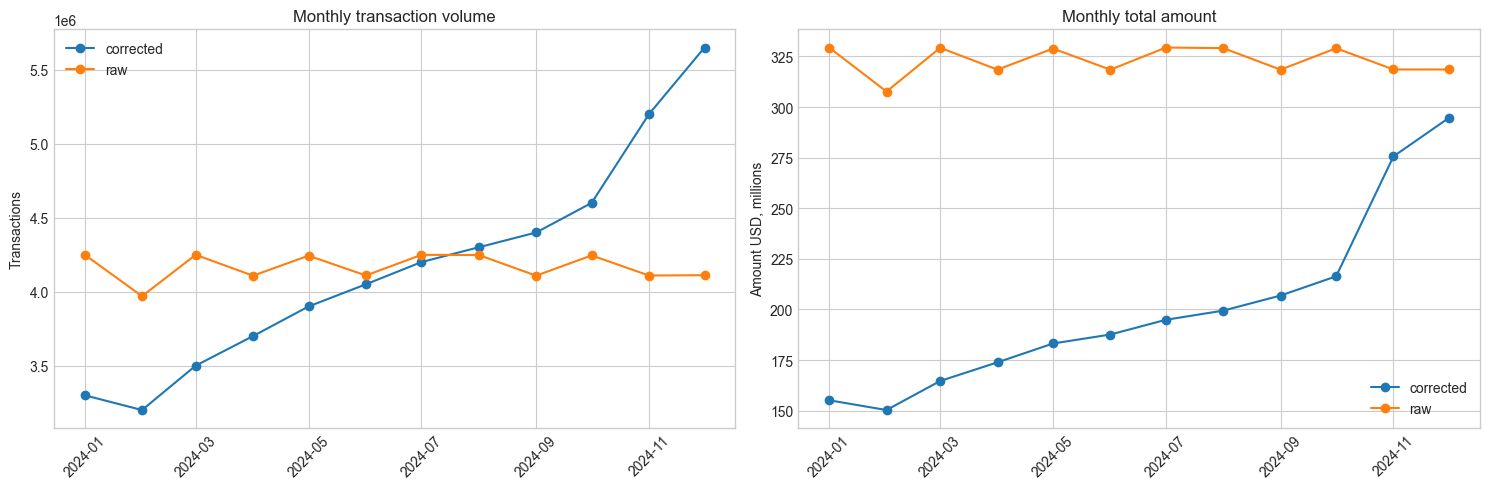

In [5]:
def monthly_kpis(name: str, lf: pl.LazyFrame) -> pl.DataFrame:
    return (
        lf.group_by("Month")
        .agg(
            pl.len().alias("n_transactions"),
            pl.col("User_ID").n_unique().alias("active_users"),
            pl.col("Amount_USD").sum().alias("total_amount_usd"),
            pl.col("Amount_USD").mean().alias("avg_amount_usd"),
            (pl.col("Status") == "Completed").mean().alias("completion_rate"),
        )
        .with_columns(pl.lit(name).alias("dataset"))
        .sort("Month")
        .collect()
    )

monthly = pl.concat([
    monthly_kpis("raw", raw_interactions),
    monthly_kpis("corrected", corrected_interactions),
])
monthly_pd = monthly.to_pandas()
display(monthly_pd)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for dataset, df in monthly_pd.groupby("dataset"):
    axes[0].plot(df["Month"], df["n_transactions"], marker="o", label=dataset)
    axes[1].plot(df["Month"], df["total_amount_usd"] / 1_000_000, marker="o", label=dataset)
axes[0].set_title("Monthly transaction volume")
axes[0].set_ylabel("Transactions")
axes[1].set_title("Monthly total amount")
axes[1].set_ylabel("Amount USD, millions")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
plt.tight_layout()
plt.show()

,dataset,n_dates,avg_daily_transactions,std_daily_transactions,daily_cv
0,corrected,366,136612.021858,24087.567208,0.176321
1,raw,365,136986.301370,368.603881,0.002691


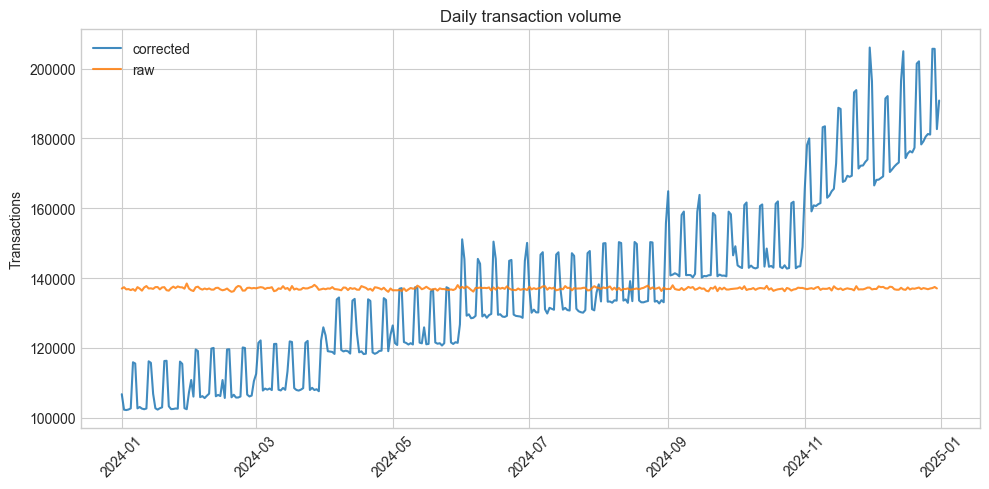

In [6]:
daily = pl.concat([
    raw_interactions.group_by("Date").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("raw").alias("dataset")).collect(),
    corrected_interactions.group_by("Date").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("corrected").alias("dataset")).collect(),
])

daily_stats = (
    daily.group_by("dataset")
    .agg(
        pl.len().alias("n_dates"),
        pl.col("n_transactions").mean().alias("avg_daily_transactions"),
        pl.col("n_transactions").std().alias("std_daily_transactions"),
        (pl.col("n_transactions").std() / pl.col("n_transactions").mean()).alias("daily_cv"),
    )
    .sort("dataset")
)
display(daily_stats.to_pandas())

daily_pd = daily.sort(["dataset", "Date"]).to_pandas()
for dataset, df in daily_pd.groupby("dataset"):
    plt.plot(df["Date"], df["n_transactions"], alpha=0.85, label=dataset)
plt.title("Daily transaction volume")
plt.ylabel("Transactions")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 5. Category behavior

Corrected categories should differ by basket size and completion behavior. Raw category averages were almost identical.

,Category,n_transactions,active_users,avg_amount_usd,median_amount_usd,completion_rate,transaction_share,dataset
0,Digital Wallet,4998004,1835664,77.485762,77.47,0.899899,0.099960,raw
1,E-Commerce,9997890,1986665,77.478125,77.47,0.900000,0.199958,raw
2,Food Delivery,20003439,1999892,77.512168,77.52,0.899976,0.400069,raw
3,Grocery,4998923,1836666,77.511723,77.54,0.900299,0.099978,raw
4,Ride Hailing,10001744,1986565,77.493836,77.50,0.900021,0.200035,raw
5,Digital Wallet,6038348,1343351,42.355988,23.72,0.978520,0.120767,corrected
6,E-Commerce,11015252,1544827,88.513369,65.34,0.872322,0.220305,corrected
7,Food Delivery,14761005,1609691,26.924710,24.67,0.943367,0.295220,corrected
8,Grocery,7287050,1411065,67.007112,62.90,0.918439,0.145741,corrected
9,Ride Hailing,10898345,1537769,26.264549,23.15,0.888296,0.217967,corrected


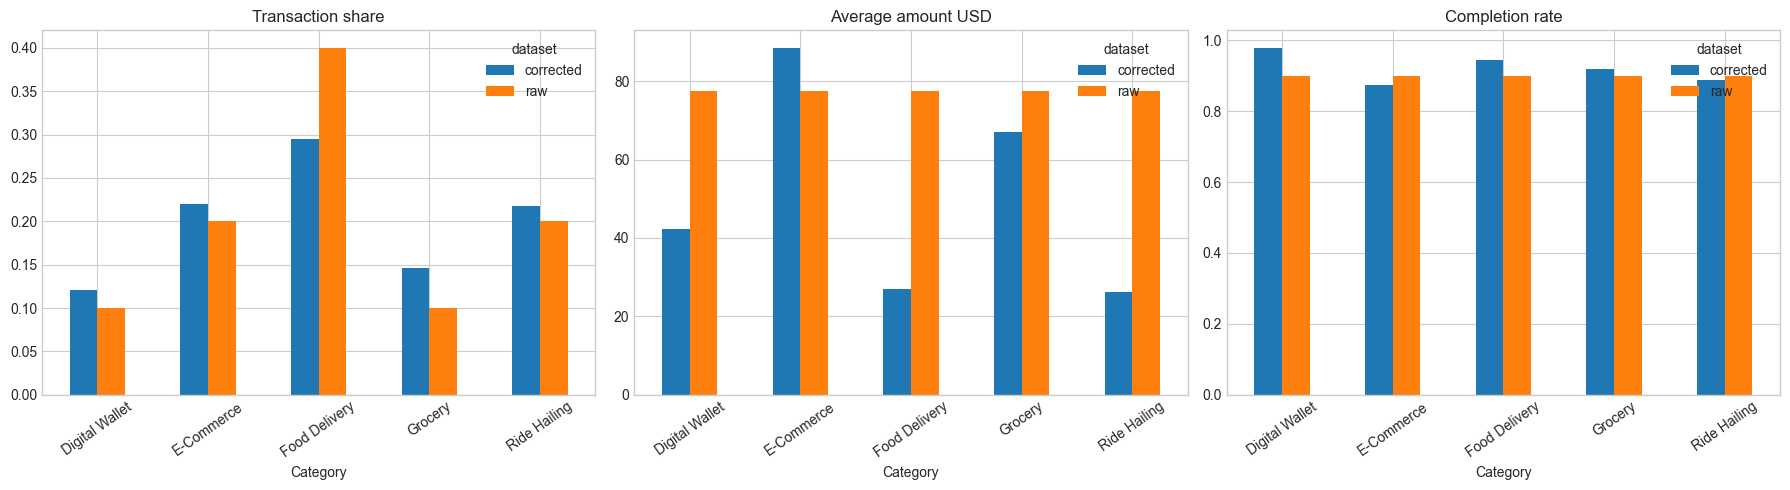

In [7]:
def category_kpis(name: str, lf: pl.LazyFrame) -> pl.DataFrame:
    return (
        lf.group_by("Category")
        .agg(
            pl.len().alias("n_transactions"),
            pl.col("User_ID").n_unique().alias("active_users"),
            pl.col("Amount_USD").mean().alias("avg_amount_usd"),
            pl.col("Amount_USD").median().alias("median_amount_usd"),
            (pl.col("Status") == "Completed").mean().alias("completion_rate"),
        )
        .with_columns(
            (pl.col("n_transactions") / pl.col("n_transactions").sum()).alias("transaction_share"),
            pl.lit(name).alias("dataset"),
        )
        .sort(["dataset", "Category"])
        .collect()
    )

category_compare = pl.concat([
    category_kpis("raw", raw_interactions),
    category_kpis("corrected", corrected_interactions),
])
cat_pd = category_compare.to_pandas()
display(cat_pd)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for metric, ax, title in [
    ("transaction_share", axes[0], "Transaction share"),
    ("avg_amount_usd", axes[1], "Average amount USD"),
    ("completion_rate", axes[2], "Completion rate"),
]:
    pivot = cat_pd.pivot(index="Category", columns="dataset", values=metric).sort_index()
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

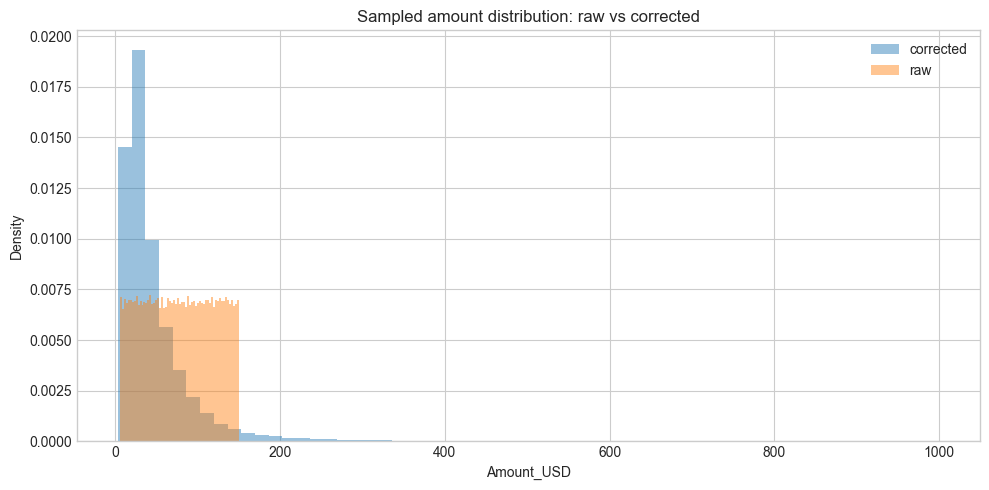

/var/folders/28/8k26_pcd2bz699b6mx6vz2yc0000gn/T/ipykernel_80144/3653704754.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([corrected_amounts.loc[corrected_amounts["Category"] == cat, "Amount_USD"] for cat in order], labels=order, showfliers=False)


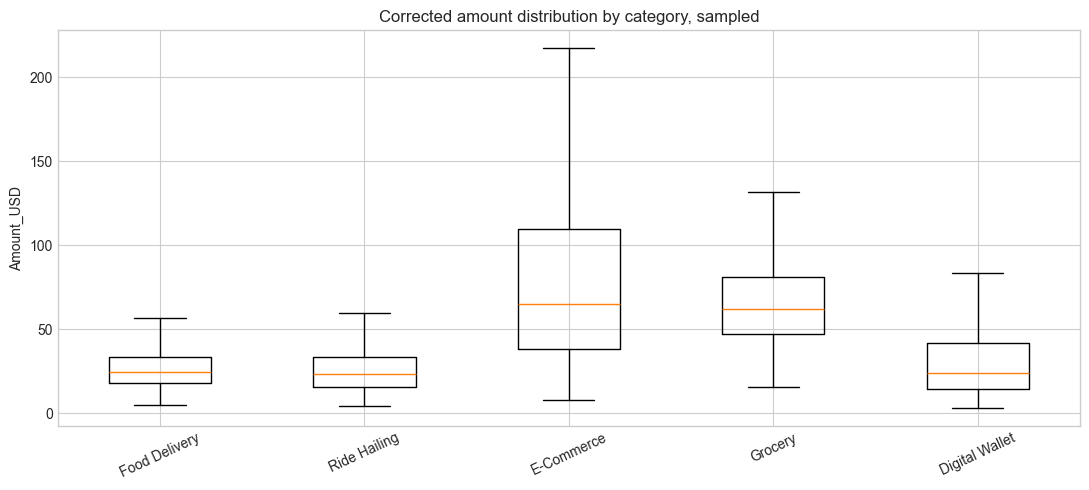

In [8]:
sample_mod = 500
amount_sample = pl.concat([
    raw_interactions
    .filter(pl.col("Transaction_UUID").hash(seed=42).mod(sample_mod) == 0)
    .select("Amount_USD", "Category")
    .with_columns(pl.lit("raw").alias("dataset"))
    .collect(),
    corrected_interactions
    .filter(pl.col("Transaction_UUID").hash(seed=42).mod(sample_mod) == 0)
    .select("Amount_USD", "Category")
    .with_columns(pl.lit("corrected").alias("dataset"))
    .collect(),
])
amount_pd = amount_sample.to_pandas()

plt.figure(figsize=(10, 5))
for dataset, df in amount_pd.groupby("dataset"):
    plt.hist(df["Amount_USD"], bins=60, alpha=0.45, density=True, label=dataset)
plt.title("Sampled amount distribution: raw vs corrected")
plt.xlabel("Amount_USD")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

corrected_amounts = amount_pd[amount_pd["dataset"] == "corrected"]
order = ["Food Delivery", "Ride Hailing", "E-Commerce", "Grocery", "Digital Wallet"]
plt.figure(figsize=(11, 5))
plt.boxplot([corrected_amounts.loc[corrected_amounts["Category"] == cat, "Amount_USD"] for cat in order], labels=order, showfliers=False)
plt.title("Corrected amount distribution by category, sampled")
plt.ylabel("Amount_USD")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 6. Hourly behavior

Raw hourly counts were almost perfectly flat. Corrected hourly behavior should have category-specific peaks.

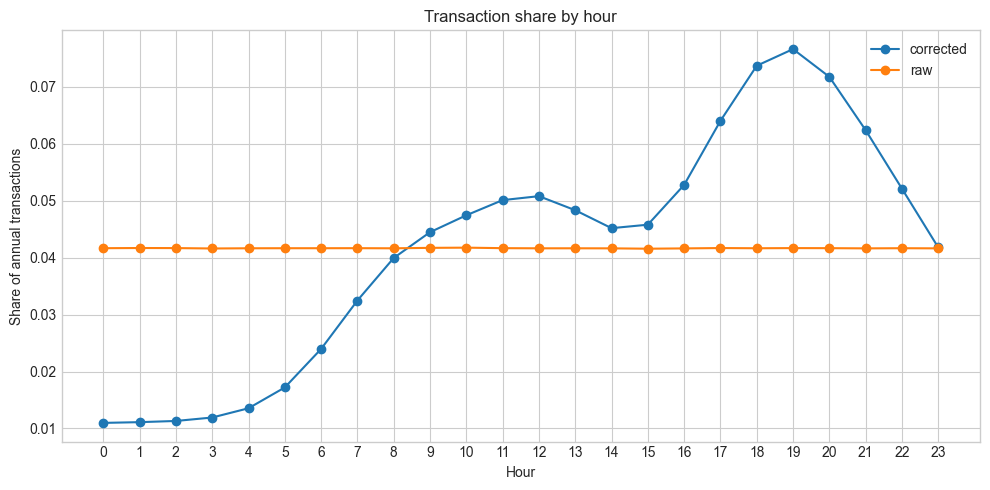

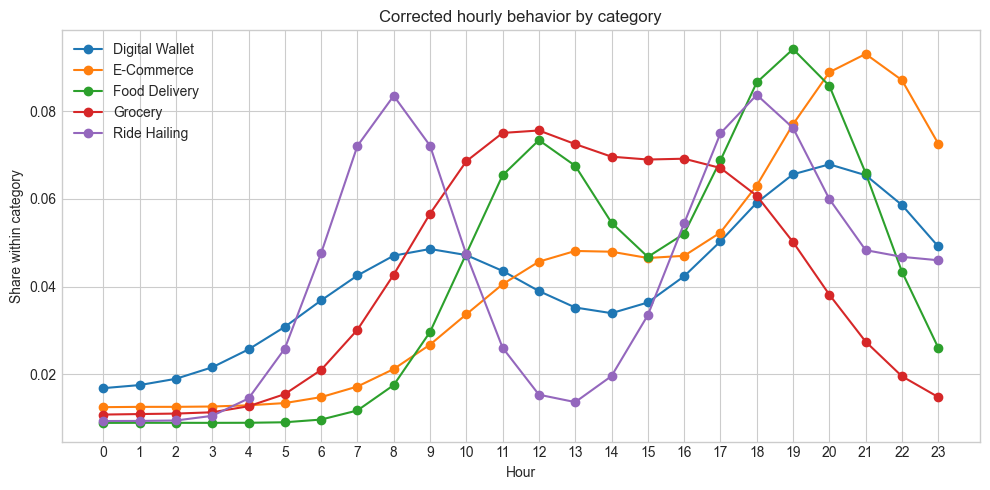

In [9]:
hourly_raw = raw_interactions.group_by("Hour").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("raw").alias("dataset")).collect()
hourly_corrected = corrected_interactions.group_by("Hour").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("corrected").alias("dataset")).collect()
hourly_compare = pl.concat([hourly_raw, hourly_corrected]).with_columns(
    (pl.col("n_transactions") / pl.col("n_transactions").sum().over("dataset")).alias("share")
)

hourly_pd = hourly_compare.sort(["dataset", "Hour"]).to_pandas()
for dataset, df in hourly_pd.groupby("dataset"):
    plt.plot(df["Hour"], df["share"], marker="o", label=dataset)
plt.title("Transaction share by hour")
plt.xlabel("Hour")
plt.ylabel("Share of annual transactions")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

hourly_category = (
    corrected_interactions.group_by(["Category", "Hour"])
    .agg(pl.len().alias("n_transactions"))
    .with_columns((pl.col("n_transactions") / pl.col("n_transactions").sum().over("Category")).alias("share"))
    .sort(["Category", "Hour"])
    .collect()
)
hourly_cat_pd = hourly_category.to_pandas()
for category, df in hourly_cat_pd.groupby("Category"):
    plt.plot(df["Hour"], df["share"], marker="o", label=category)
plt.title("Corrected hourly behavior by category")
plt.xlabel("Hour")
plt.ylabel("Share within category")
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.show()

## 7. Reliability by platform and category

Corrected completion and failure rates should vary by category and platform instead of staying fixed around 90/5/5 everywhere.

,Category,Status,n_transactions,dataset,status_share
0,Digital Wallet,Completed,5908647,corrected,0.978520
1,Digital Wallet,Failed,116756,corrected,0.019336
2,Digital Wallet,Refunded,12945,corrected,0.002144
3,E-Commerce,Completed,9608851,corrected,0.872322
4,E-Commerce,Failed,451505,corrected,0.040989
5,E-Commerce,Refunded,954896,corrected,0.086689
6,Food Delivery,Completed,13925047,corrected,0.943367
7,Food Delivery,Failed,543870,corrected,0.036845
8,Food Delivery,Refunded,292088,corrected,0.019788
9,Grocery,Completed,6692709,corrected,0.918439


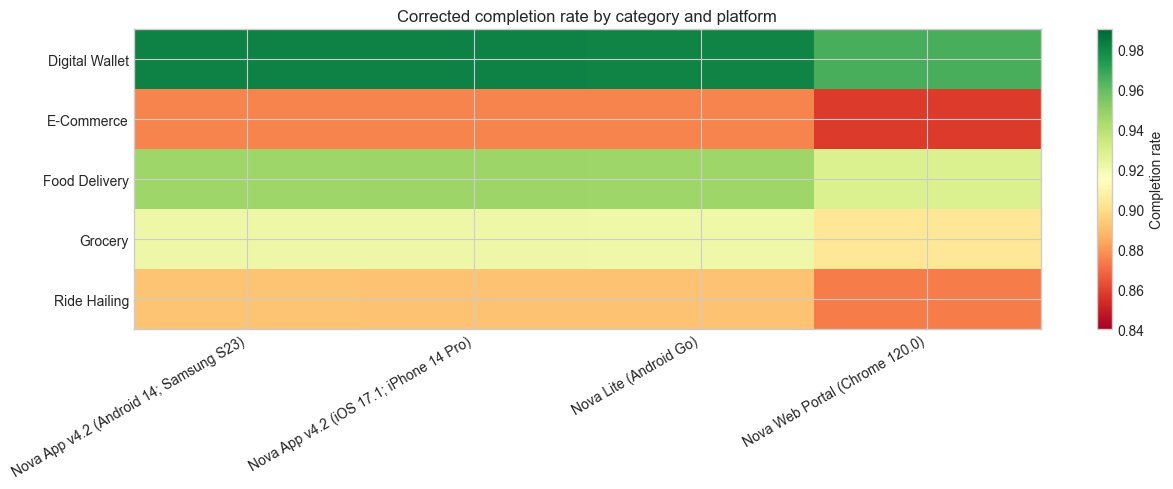

In [10]:
status_category = pl.concat([
    raw_interactions.group_by(["Category", "Status"]).agg(pl.len().alias("n_transactions")).with_columns(pl.lit("raw").alias("dataset")).collect(),
    corrected_interactions.group_by(["Category", "Status"]).agg(pl.len().alias("n_transactions")).with_columns(pl.lit("corrected").alias("dataset")).collect(),
]).with_columns(
    (pl.col("n_transactions") / pl.col("n_transactions").sum().over(["dataset", "Category"])).alias("status_share")
)
display(status_category.sort(["dataset", "Category", "Status"]).to_pandas())

completion_platform = (
    corrected_interactions.group_by(["Category", "Platform_User_Agent"])
    .agg((pl.col("Status") == "Completed").mean().alias("completion_rate"))
    .sort(["Category", "Platform_User_Agent"])
    .collect()
    .to_pandas()
)
pivot = completion_platform.pivot(index="Category", columns="Platform_User_Agent", values="completion_rate")

plt.figure(figsize=(13, 5))
plt.imshow(pivot.values, aspect="auto", vmin=0.84, vmax=0.99, cmap="RdYlGn")
plt.colorbar(label="Completion rate")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=30, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Corrected completion rate by category and platform")
plt.tight_layout()
plt.show()

## 8. Merchant concentration

A real super-app should have head merchants and long-tail merchants. The raw service counts were clustered around exactly 1,000 transactions per service.

,dataset,n_services,mean_transactions,std_transactions,cv_transactions,top_1pct_share,top_10_services_share
0,raw,50000,1000.0,31.567615,0.031568,0.010862,0.000225
1,corrected,50000,1000.0,2377.391548,2.377392,0.205995,0.009113


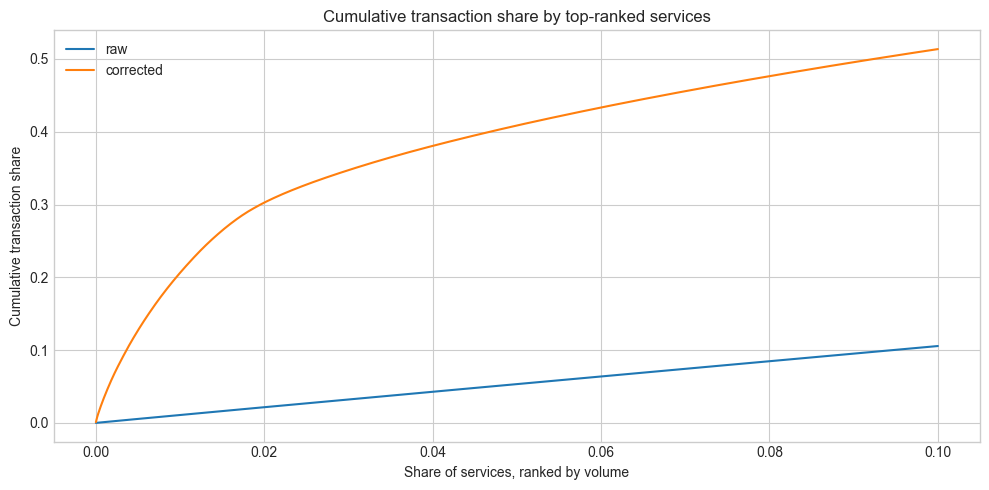

In [11]:
def service_concentration(name: str, lf: pl.LazyFrame) -> tuple[pl.DataFrame, dict]:
    counts = lf.group_by("Service_ID").agg(pl.len().alias("n_transactions")).sort("n_transactions", descending=True).collect()
    total = counts["n_transactions"].sum()
    top_1pct_n = max(1, int(counts.height * 0.01))
    stats = {
        "dataset": name,
        "n_services": counts.height,
        "mean_transactions": counts["n_transactions"].mean(),
        "std_transactions": counts["n_transactions"].std(),
        "cv_transactions": counts["n_transactions"].std() / counts["n_transactions"].mean(),
        "top_1pct_share": counts.head(top_1pct_n)["n_transactions"].sum() / total,
        "top_10_services_share": counts.head(10)["n_transactions"].sum() / total,
    }
    return counts.with_columns(pl.lit(name).alias("dataset")), stats

raw_service_counts, raw_service_stats = service_concentration("raw", raw_interactions)
corrected_service_counts, corrected_service_stats = service_concentration("corrected", corrected_interactions)
service_stats = pd.DataFrame([raw_service_stats, corrected_service_stats])
display(service_stats)

plt.figure(figsize=(10, 5))
for counts_df, label in [(raw_service_counts, "raw"), (corrected_service_counts, "corrected")]:
    counts = counts_df["n_transactions"].to_numpy()
    cumulative_share = np.cumsum(counts) / counts.sum()
    service_rank_share = np.arange(1, len(counts) + 1) / len(counts)
    plt.plot(service_rank_share[:5000], cumulative_share[:5000], label=label)
plt.title("Cumulative transaction share by top-ranked services")
plt.xlabel("Share of services, ranked by volume")
plt.ylabel("Cumulative transaction share")
plt.legend()
plt.tight_layout()
plt.show()

## 9. User lifecycle and corrected dimensions

The corrected user table adds lifecycle and market fields so dashboard segments are not all identical.

,User_Segment,Lifecycle_Segment,Membership_Tier,n_users,user_share
0,Casual,Retained,Standard,548110,0.274055
1,Regular,Retained,Standard,431659,0.215829
2,Dormant,Inactive,Standard,300003,0.150001
3,Casual,At Risk,Standard,213253,0.106626
4,Regular,Retained,Gold,168173,0.084086
5,New,New Active,Standard,139728,0.069864
6,Power,High Value,Gold,72682,0.036341
7,Power,High Value,Standard,66716,0.033358
8,Power,High Value,Platinum,59676,0.029838


,dataset,active_users,avg_transactions,median_transactions,p95_transactions
0,raw,2000000,25.000000,25.0,33.0
1,corrected,1698906,29.430704,14.0,124.0


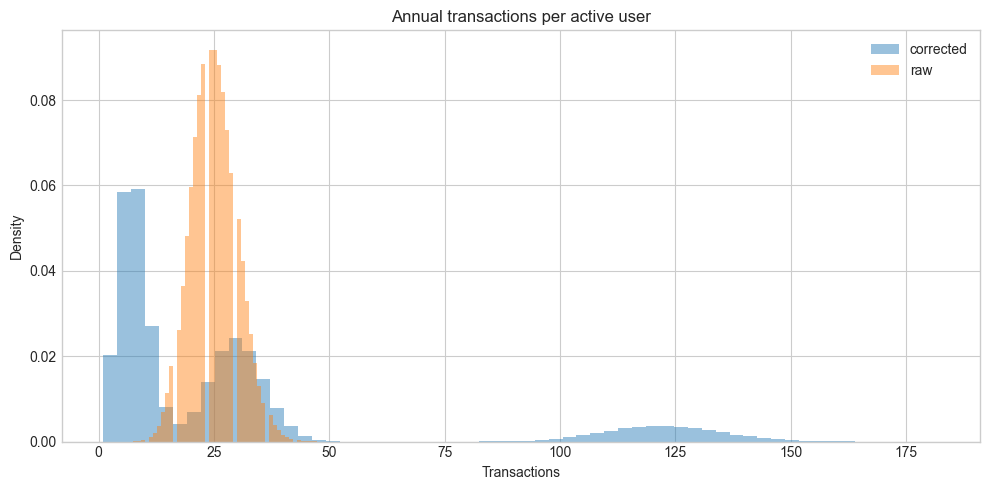

In [12]:
user_segment_profile = (
    corrected_users.group_by(["User_Segment", "Lifecycle_Segment", "Membership_Tier"])
    .agg(pl.len().alias("n_users"))
    .with_columns((pl.col("n_users") / corrected_users.height).alias("user_share"))
    .sort("n_users", descending=True)
)
display(user_segment_profile.to_pandas())

active_user_counts = pl.concat([
    raw_interactions.group_by("User_ID").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("raw").alias("dataset")).collect(),
    corrected_interactions.group_by("User_ID").agg(pl.len().alias("n_transactions")).with_columns(pl.lit("corrected").alias("dataset")).collect(),
])
activity_stats = (
    active_user_counts.group_by("dataset")
    .agg(
        pl.len().alias("active_users"),
        pl.col("n_transactions").mean().alias("avg_transactions"),
        pl.col("n_transactions").median().alias("median_transactions"),
        pl.col("n_transactions").quantile(0.95).alias("p95_transactions"),
    )
)
display(activity_stats.to_pandas())

activity_pd = active_user_counts.to_pandas()
plt.figure(figsize=(10, 5))
for dataset, df in activity_pd.groupby("dataset"):
    plt.hist(df["n_transactions"], bins=60, alpha=0.45, density=True, label=dataset)
plt.title("Annual transactions per active user")
plt.xlabel("Transactions")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Markets and geography

Raw GPS was globally uniform. Corrected GPS is market-centered and should support realistic market maps.

,Market_ID,Market_Name,Region,n_transactions,active_users,total_amount_usd,transaction_share
0,2,Jakarta,Southeast Asia,4711771,153184,2.264457e+08,0.094235
1,13,Mumbai,South Asia,4258852,135870,2.045851e+08,0.085177
2,3,Manila,Southeast Asia,3862139,127918,1.854625e+08,0.077243
3,14,Bangalore,South Asia,3694027,118815,1.775174e+08,0.073881
4,1,Singapore,Southeast Asia,3352367,118547,1.610728e+08,0.067047
5,4,Bangkok,Southeast Asia,3229663,110298,1.552501e+08,0.064593
6,6,Istanbul,EMEA,3204170,110145,1.540076e+08,0.064083
7,5,Ho Chi Minh City,Southeast Asia,3114826,102159,1.497127e+08,0.062297
8,10,New York,North America,2997731,110138,1.439793e+08,0.059955
9,12,Sao Paulo,Latin America,2982951,101805,1.434648e+08,0.059659


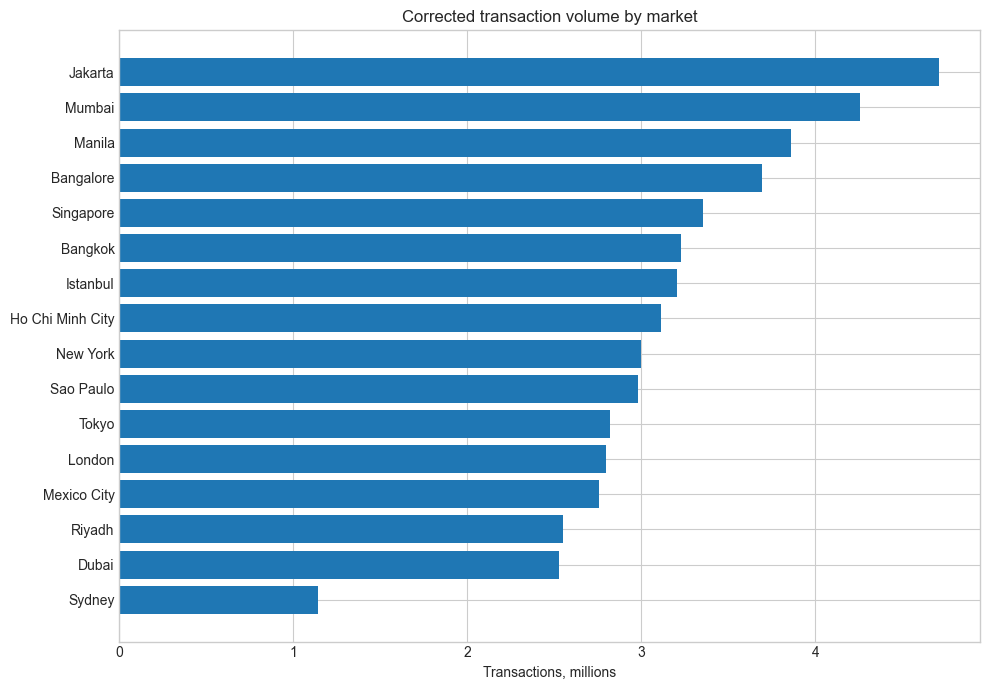

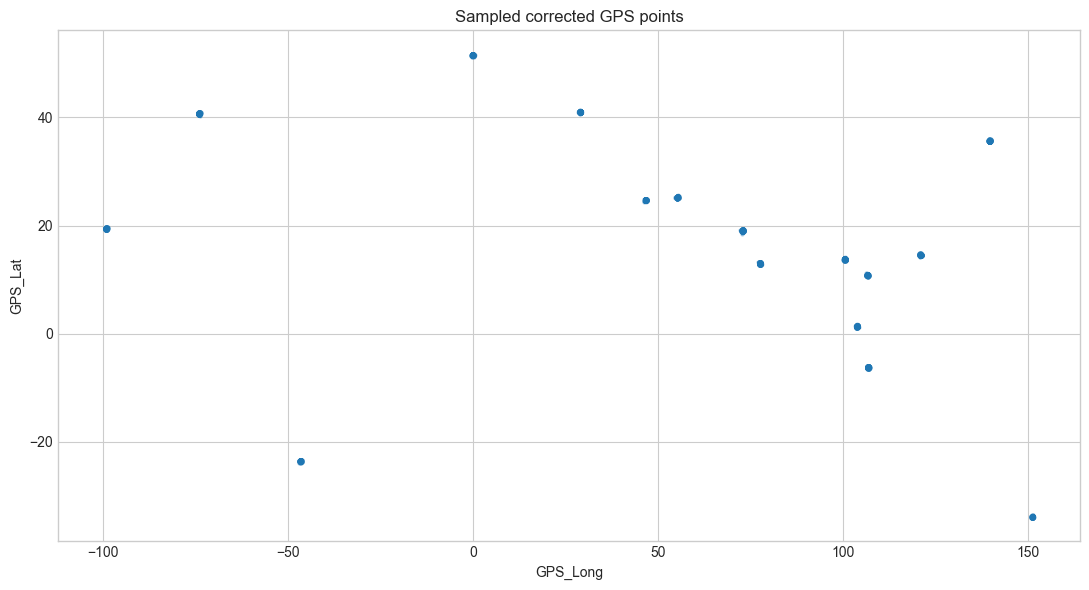

In [13]:
market_kpis = (
    corrected_interactions.group_by(["Market_ID", "Market_Name", "Region"])
    .agg(
        pl.len().alias("n_transactions"),
        pl.col("User_ID").n_unique().alias("active_users"),
        pl.col("Amount_USD").sum().alias("total_amount_usd"),
    )
    .with_columns((pl.col("n_transactions") / pl.col("n_transactions").sum()).alias("transaction_share"))
    .sort("n_transactions", descending=True)
    .collect()
)
display(market_kpis.to_pandas())

market_pd = market_kpis.to_pandas().sort_values("n_transactions")
plt.figure(figsize=(10, 7))
plt.barh(market_pd["Market_Name"], market_pd["n_transactions"] / 1_000_000)
plt.title("Corrected transaction volume by market")
plt.xlabel("Transactions, millions")
plt.tight_layout()
plt.show()

geo_sample = (
    corrected_interactions
    .filter(pl.col("Transaction_UUID").hash(seed=7).mod(5000) == 0)
    .select("GPS_Long", "GPS_Lat", "Market_Name")
    .collect()
    .to_pandas()
)
plt.figure(figsize=(11, 6))
plt.scatter(geo_sample["GPS_Long"], geo_sample["GPS_Lat"], s=4, alpha=0.35)
plt.title("Sampled corrected GPS points")
plt.xlabel("GPS_Long")
plt.ylabel("GPS_Lat")
plt.tight_layout()
plt.show()

## 11. Interpretation checklist

The corrected dataset now supports a more credible business narrative:

- Growth: monthly transactions rise through 2024 and Q4 is stronger.
- Seasonality: daily and hourly profiles are no longer flat.
- Category realism: amount and reliability differ by category.
- Platform realism: web has lower completion than native app surfaces.
- Merchant realism: service volume has a head/mid/long-tail shape.
- Geography: transactions belong to named global city markets instead of random world coordinates.
- Lifecycle: not every user is identical; corrected users include lifecycle and activity segments.

Use `data/corrected/` for BigQuery ingestion after the validation checks remain green.